In [390]:
# Import all relevant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from IPython.display import display

 
## This statement allows the visuals to render within your Jupyter Notebook.
# %matplotlib inline

## Loading the data


In [391]:
# Read in the Excel file and convert it to a Pandas DataFrame
word_df=pd.read_excel("Data/Word Rank University.xlsx")
times_df = pd.read_csv("Data/2022_rankings.csv")
shanghai_df = pd.read_excel('Data/shanghai Ranking.xlsx')

# Read in the Excel file and convert it to a Pandas DataFrame
#word_df=pd.read_excel("Word Rank University.xlsx")

# If the following datasets are not relevant, they can be ignored:
#times_df = pd.read_excel("Times Higher Education.xlsx")
#shanghai_df = pd.read_excel('shanghai Ranking.xlsx')

### Viewing the dataframe


In [392]:
#1- Display the first & last five rows of the DataFrames
word_df.head()

,World Rank,University Names,Location,National Rank,Educational Rank,Employability Rank,Faculty Rank,Research Rank,Score
0,1Top 0.1%,Harvard University\n CWUR Rating System: Ed...,USA,1,1,1,1,1,100.0
1,2Top 0.1%,Massachusetts Institute of Technology\n Educa...,USA,2,4,12,3,9,96.7
2,3Top 0.1%,Stanford University\n Education: A+; Employab...,USA,3,11,4,2,2,95.2
3,4Top 0.1%,University of Cambridge\n Education: A+; Empl...,United Kingdom,1,3,25,5,11,94.1
4,5Top 0.1%,University of Oxford\n Education: A+; Employa...,United Kingdom,2,7,27,9,4,93.3


In [393]:
word_df.tail()

,World Rank,University Names,Location,National Rank,Educational Rank,Employability Rank,Faculty Rank,Research Rank,Score
1995,1996Top 9.8%,Chongqing Jiaotong University,China,314,-,-,-,1917,66.0
1996,1997Top 9.8%,University of Arkansas at Little Rock,USA,332,-,1322,-,1920,66.0
1997,1998Top 9.8%,Van Yüzüncü Yıl University,Turkey,54,-,-,-,1919,66.0
1998,1999Top 9.8%,Bharathidasan University,India,64,-,-,-,1922,66.0
1999,2000Top 9.8%,Gebze Technical University,Turkey,55,-,-,-,1923,66.0


In [394]:
times_df.head()

,rank_order,rank,name,scores_overall,scores_overall_rank,scores_teaching,scores_teaching_rank,scores_research,scores_research_rank,scores_citations,scores_citations_rank,scores_industry_income,scores_industry_income_rank,scores_international_outlook,scores_international_outlook_rank,location
0,10,1,University of Oxford,95.7,10,91.0,5,99.6,1,98.0,40,74.4,161,96.3,26,United Kingdom
1,20,2,California Institute of Technology,95.0,20,93.6,2,96.9,4,97.8,44,90.4,78,83.8,167,United States
2,30,2,Harvard University,95.0,30,94.5,1,98.9,3,99.2,19,48.9,418,79.8,209,United States
3,40,4,Stanford University,94.9,40,92.3,3,96.8,5,99.9,13,91.0,74,79.7,211,United States
4,50,5,University of Cambridge,94.6,50,90.9,6,99.5,2,96.2,65,56.7,300,95.8,32,United Kingdom


In [395]:
times_df.tail(1000)

,rank_order,rank,name,scores_overall,scores_overall_rank,scores_teaching,scores_teaching_rank,scores_research,scores_research_rank,scores_citations,scores_citations_rank,scores_industry_income,scores_industry_income_rank,scores_international_outlook,scores_international_outlook_rank,location
1112,11130,1001–1200,National Central University,22.4–27.1,11130,26.1,648,23.5,563,18.2,1359,75.8,151,45.4,745,Taiwan
1113,11140,1001–1200,National Chengchi University,22.4–27.1,11140,25.1,716,28.5,426,12.6,1517,42.7,619,50.0,635,Taiwan
1114,11150,1001–1200,National University of Colombia,22.4–27.1,11150,20.3,1077,14.1,1014,41.4,908,35.3,1399,36.9,984,Colombia
1115,11160,1001–1200,National Dong Hwa University,22.4–27.1,11160,18.4,1262,22.0,617,26.1,1181,38.3,944,43.3,806,Taiwan
1116,11170,1001–1200,"National Institute of Technology, Tiruchirappalli",22.4–27.1,11170,26.1,649,13.7,1041,35.4,1015,39.7,808,23.2,1400,India
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2107,1000446,Reporter,Yaşar University,NaN,1000446,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,Turkey
2108,1000447,Reporter,Yenepoya University,NaN,1000447,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,India
2109,1000448,Reporter,Yogyakarta State University,NaN,1000448,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,Indonesia
2110,1000449,Reporter,York St John University,NaN,1000449,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,United Kingdom


In [396]:
shanghai_df.head()

,Ranking,University Name,National/Regional Rank,Total Score,LOGO,University Detail
0,1,Harvard University,1,100.0,http://www.shanghairanking.com/_uni/logo/032bd...,http://www.shanghairanking.com/institution/har...
1,2,Stanford University,2,76.8,http://www.shanghairanking.com/_uni/logo/13de8...,http://www.shanghairanking.com/institution/sta...
2,3,Massachusetts Institute of Technology (MIT),3,70.1,http://www.shanghairanking.com/_uni/logo/79165...,http://www.shanghairanking.com/institution/mas...
3,4,University of Cambridge,1,69.6,http://www.shanghairanking.com/_uni/logo/8d986...,http://www.shanghairanking.com/institution/uni...
4,5,"University of California, Berkeley",4,65.3,http://www.shanghairanking.com/_uni/logo/0ff17...,http://www.shanghairanking.com/institution/uni...


In [397]:
shanghai_df.tail()

,Ranking,University Name,National/Regional Rank,Total Score,LOGO,University Detail
995,901-1000,University of Wuppertal,46-47,0.0,http://www.shanghairanking.com/_uni/logo/2ab2f...,http://www.shanghairanking.com/institution/uni...
996,901-1000,Warsaw University of Technology,7-11,0.0,http://www.shanghairanking.com/_uni/logo/a347c...,http://www.shanghairanking.com/institution/war...
997,901-1000,Western Norway University of Applied Sciences,6-7,0.0,http://www.shanghairanking.com/_uni/logo-jpg/d...,http://www.shanghairanking.com/institution/wes...
998,901-1000,Wroclaw University of Science and Technology,7-11,0.0,http://www.shanghairanking.com/_uni/logo/ed480...,http://www.shanghairanking.com/institution/wro...
999,901-1000,Yantai University,148-163,0.0,http://www.shanghairanking.com/_uni/logo/78347...,http://www.shanghairanking.com/institution/yan...


In [398]:
#2- Get the shape of the DataFrame
word_df.shape, times_df.shape, shanghai_df.shape

((2000, 9), (2112, 16), (1000, 6))

## 1. Data Profiling:


In [399]:
# 1- Disblay all columns
word_df.columns

Index(['World Rank', 'University Names', 'Location ', 'National Rank',
       'Educational Rank', 'Employability Rank', 'Faculty Rank',
       'Research Rank', 'Score'],
      dtype='object')

In [400]:
times_df.columns

Index(['rank_order', 'rank', 'name', 'scores_overall', 'scores_overall_rank',
       'scores_teaching', 'scores_teaching_rank', 'scores_research',
       'scores_research_rank', 'scores_citations', 'scores_citations_rank',
       'scores_industry_income', 'scores_industry_income_rank',
       'scores_international_outlook', 'scores_international_outlook_rank',
       'location'],
      dtype='object')

In [401]:
shanghai_df.columns

Index(['Ranking', 'University Name', 'National/Regional Rank', 'Total Score',
       'LOGO', 'University Detail '],
      dtype='object')

In [402]:
# 2- Disblay all information available
word_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   World Rank          2000 non-null   object 
 1   University Names    2000 non-null   object 
 2   Location            2000 non-null   object 
 3   National Rank       2000 non-null   int64  
 4   Educational Rank    2000 non-null   object 
 5   Employability Rank  2000 non-null   object 
 6   Faculty Rank        2000 non-null   object 
 7   Research Rank       2000 non-null   object 
 8   Score               2000 non-null   float64
dtypes: float64(1), int64(1), object(7)
memory usage: 140.8+ KB


In [403]:
times_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2112 entries, 0 to 2111
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   rank_order                         2112 non-null   int64  
 1   rank                               2112 non-null   object 
 2   name                               2112 non-null   object 
 3   scores_overall                     1662 non-null   object 
 4   scores_overall_rank                2112 non-null   int64  
 5   scores_teaching                    1662 non-null   float64
 6   scores_teaching_rank               2112 non-null   int64  
 7   scores_research                    1662 non-null   float64
 8   scores_research_rank               2112 non-null   int64  
 9   scores_citations                   1662 non-null   float64
 10  scores_citations_rank              2112 non-null   int64  
 11  scores_industry_income             1662 non-null   float

In [404]:
shanghai_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Ranking                 1000 non-null   object 
 1   University Name         1000 non-null   object 
 2   National/Regional Rank  1000 non-null   object 
 3   Total Score             1000 non-null   float64
 4   LOGO                    1000 non-null   object 
 5   University Detail       1000 non-null   object 
dtypes: float64(1), object(5)
memory usage: 47.0+ KB


In [405]:
# 3- Display summary statistics for categorical columns
word_df.describe(include="object")

,World Rank,University Names,Location,Educational Rank,Employability Rank,Faculty Rank,Research Rank
count,2000,2000,2000,2000,2000,2000,2000
unique,2000,2000,95,439,1030,262,1935
top,1Top 0.1%,Harvard University\n CWUR Rating System: Ed...,USA,-,-,-,-
freq,1,1,332,1562,967,1727,66


In [406]:
times_df.describe(include="object")

,rank,name,scores_overall,location
count,2112,2112,1662,2112
unique,144,2112,143,111
top,1201,University of Oxford,10.6–22.3,United States
freq,461,1,461,188


In [407]:
shanghai_df.describe(include="object")

,Ranking,University Name,National/Regional Rank,LOGO,University Detail
count,1000,1000,1000,1000,1000
unique,93,1000,136,1000,1000
top,901-1000,Harvard University,1,http://www.shanghairanking.com/_uni/logo/032bd...,http://www.shanghairanking.com/institution/har...
freq,100,1,59,1,1


In [408]:
# 4- Display summary statistics for numerical columns
word_df.describe(include="number")

,National Rank,Score
count,2000.000000,2000.00000
mean,69.245000,71.75555
std,85.538608,5.03880
min,1.000000,66.00000
25%,9.750000,67.90000
50%,33.000000,70.40000
75%,89.000000,74.30000
max,332.000000,100.00000


In [409]:
times_df.describe(include="number")

,rank_order,scores_overall_rank,scores_teaching,scores_teaching_rank,scores_research,scores_research_rank,scores_citations,scores_citations_rank,scores_industry_income,scores_industry_income_rank,scores_international_outlook,scores_international_outlook_rank
count,2.112000e+03,2.112000e+03,1662.000000,2112.000000,1662.000000,2112.000000,1662.000000,2112.000000,1662.000000,2112.000000,1662.000000,2112.000000
mean,2.196596e+05,2.196596e+05,27.460529,654.333807,23.077497,654.333807,48.088327,654.333807,46.599338,654.333807,46.943562,654.333807
std,4.062815e+05,4.062815e+05,13.220974,545.167829,16.745298,545.167829,27.570528,545.167829,16.429355,545.167829,22.950696,545.167829
min,1.000000e+01,1.000000e+01,11.900000,0.000000,7.400000,0.000000,0.700000,0.000000,34.800000,0.000000,13.800000,0.000000
25%,5.287500e+03,5.287500e+03,18.500000,78.750000,11.600000,78.750000,23.225000,78.750000,35.925000,78.750000,27.400000,78.750000
50%,1.056500e+04,1.056500e+04,23.300000,606.500000,17.100000,606.500000,46.200000,606.500000,39.500000,606.500000,42.300000,606.500000
75%,1.584250e+04,1.584250e+04,32.000000,1134.250000,28.900000,1134.250000,70.900000,1134.250000,48.900000,1134.250000,62.575000,1134.250000
max,1.000450e+06,1.000450e+06,94.500000,1662.000000,99.600000,1662.000000,100.000000,1662.000000,100.000000,1662.000000,99.900000,1662.000000


In [410]:
shanghai_df.describe(include="number")

,Total Score
count,1000.000000
mean,5.943500
std,12.379624
min,0.000000
25%,0.000000
50%,0.000000
75%,7.500000
max,100.000000


In [411]:
# 5- Check for duplicated values in the DataFrame
word_df.duplicated().sum()

0

In [412]:
times_df.duplicated().sum()

0

In [413]:
times_df["rank"].duplicated().sum()

1968

In [414]:
shanghai_df.duplicated().sum()

0

In [415]:
# 6- Check for universities with the same world rank
word_df["World Rank"].duplicated().sum()

0

In [416]:
# 7- Look for universities that do not have a Research Rank
no_research_rank = word_df[word_df["Research Rank"] == "-"]
no_research_rank


,World Rank,University Names,Location,National Rank,Educational Rank,Employability Rank,Faculty Rank,Research Rank,Score
210,211Top 1.1%,Institut national du service public,France,11,-,3,-,-,78.5
273,274Top 1.4%,China Europe International Business School,China,32,-,5,-,-,77.3
279,280Top 1.4%,HEC Paris,France,15,-,7,-,-,77.2
405,406Top 2%,International Institute for Management Develop...,Switzerland,8,-,10,-,-,75.3
418,419Top 2.1%,Indian Institute of Management Ahmedabad,India,1,375,11,-,-,75.2
...,...,...,...,...,...,...,...,...,...
1931,1932Top 9.5%,Institut supérieur de l'aéronautique et de l'e...,France,72,-,180,-,-,66.2
1940,1941Top 9.5%,Hamilton College,USA,328,82,255,-,-,66.2
1950,1951Top 9.6%,Drew University,USA,329,-,606,128,-,66.1
1956,1957Top 9.6%,"Graduate School & Training Center, Research In...",China,303,-,71,-,-,66.1


In [417]:
# 8- Check for duplicated Faculty Ranks
duplicated_faculty_rank = word_df["Faculty Rank"].duplicated().value_counts()
duplicated_faculty_rank


Faculty Rank
True     1738
False     262
Name: count, dtype: int64

In [418]:
# 9- Look at universities with a Faculty Rank of 128
word_df[(word_df["Faculty Rank"] == "128")]

,World Rank,University Names,Location,National Rank,Educational Rank,Employability Rank,Faculty Rank,Research Rank,Score
772,773Top 3.8%,Kitasato University,Japan,25,-,-,128,1005,71.9
1950,1951Top 9.6%,Drew University,USA,329,-,606,128,-,66.1


In [419]:
# Examine the last 10 rows to inspect any notable patterns
# The score ends with 66.0 and it can have the same score
word_df.tail(10)

,World Rank,University Names,Location,National Rank,Educational Rank,Employability Rank,Faculty Rank,Research Rank,Score
1990,1991Top 9.7%,Hunan University of Technology,China,312,-,-,-,1913,66.0
1991,1992Top 9.8%,Zurich University of Applied Sciences (ZHAW),Switzerland,13,-,909,-,1927,66.0
1992,1993Top 9.8%,Technical University of Košice,Slovak Republic,4,-,-,-,1914,66.0
1993,1994Top 9.8%,Guangdong Ocean University,China,313,-,-,-,1915,66.0
1994,1995Top 9.8%,"University of Djillali Liabès, Sidi Bel-Abbès",Algeria,2,-,-,-,1916,66.0
1995,1996Top 9.8%,Chongqing Jiaotong University,China,314,-,-,-,1917,66.0
1996,1997Top 9.8%,University of Arkansas at Little Rock,USA,332,-,1322,-,1920,66.0
1997,1998Top 9.8%,Van Yüzüncü Yıl University,Turkey,54,-,-,-,1919,66.0
1998,1999Top 9.8%,Bharathidasan University,India,64,-,-,-,1922,66.0
1999,2000Top 9.8%,Gebze Technical University,Turkey,55,-,-,-,1923,66.0


### Data Quality Checks


#### 1. Reliability:


In [420]:
# Based on Kaggle, CWUR uses various indicators like research output and quality of faculty to rank universities.

#### 2. Timeliness: 


In [421]:
# In this Usecase, timeliness may not be critical for the analysis.
# The problem does not depend on being up-to-date nor asks for a specific period of interest for the analysis.

#### 3. Consistency: 

Confirm that the data is consistent within the dataset and across multiple data sources. For example, the same data point should not have different values in different places.


In [422]:
#  

#### 4. Relevance: 
Assess whether the data is appropriate and applicable for the intended analysis. Data that is not relevant can skew results and lead to incorrect conclusions.

**Key considerations for relevance include:**

> 1. Sample Appropriateness: Confirm that your data sample aligns with your analysis objectives. For instance, utilizing data from the Northern region will not yield accurate insights for the Western region of the Kingdom.
>
> 2. Variable Selection: Any column will not be relevant for our analysis, we can get rid of these using the drop() method. We will set the “axis” argument to 1 since we’re dealing with columns, and set the “inplace” argument to True to make the change permanent.


In [423]:
# 1- Sample Appropriatness:
# Make sure there are universities located in Saudi Arabia
word_df[(word_df["Location "] == "Saudi Arabia")]

,World Rank,University Names,Location,National Rank,Educational Rank,Employability Rank,Faculty Rank,Research Rank,Score
244,245Top 1.2%,King Abdulaziz University,Saudi Arabia,1,-,1330,-,186,77.8
278,279Top 1.4%,King Abdullah University of Science and Techno...,Saudi Arabia,2,-,-,171,297,77.2
351,352Top 1.8%,King Saud University,Saudi Arabia,3,-,344,-,332,76.1
656,657Top 3.3%,King Fahd University of Petroleum and Minerals,Saudi Arabia,4,-,107,-,792,72.8
1310,1311Top 6.4%,King Saud bin Abdulaziz University for Health ...,Saudi Arabia,5,-,-,-,1255,68.8
1446,1447Top 7.1%,King Khalid University,Saudi Arabia,6,-,-,-,1385,68.1
1508,1509Top 7.4%,Taif University,Saudi Arabia,7,-,-,-,1445,67.9
1546,1547Top 7.6%,Imam Abdulrahman Bin Faisal University,Saudi Arabia,8,-,-,-,1484,67.7
1585,1586Top 7.8%,Taibah University,Saudi Arabia,9,-,-,-,1520,67.5
1710,1711Top 8.4%,Prince Sattam Bin Abdulaziz University,Saudi Arabia,10,-,-,-,1636,67.0


In [424]:
times_df[(times_df["location"] == "Saudi Arabia")]

,rank_order,rank,name,scores_overall,scores_overall_rank,scores_teaching,scores_teaching_rank,scores_research,scores_research_rank,scores_citations,scores_citations_rank,scores_industry_income,scores_industry_income_rank,scores_international_outlook,scores_international_outlook_rank,location
189,1900,190,King Abdulaziz University,54.5,1900,36.7,284,22.9,577,92.4,114,74.0,165,93.6,67,Saudi Arabia
203,2040,201–250,Alfaisal University,50.4–53.9,2040,20.2,1082,21.2,645,99.0,24,41.7,667,97.3,16,Saudi Arabia
368,3690,351–400,University of Hail,44.1–46.0,3690,18.1,1299,8.7,1567,100.0,7,40.9,721,82.0,181,Saudi Arabia
379,3800,351–400,King Fahd University of Petroleum and Minerals,44.1–46.0,3800,25.8,670,22.4,601,77.9,319,74.2,163,77.6,235,Saudi Arabia
380,3810,351–400,King Saud University,44.1–46.0,3810,26.1,647,27.8,443,70.9,417,82.6,110,82.3,177,Saudi Arabia
481,4820,401–500,University of Tabuk,40.9–44.0,4820,15.7,1563,7.8,1655,92.5,113,35.7,1304,72.9,280,Saudi Arabia
746,7470,601–800,Prince Sattam Bin Abdulaziz University,32.0–37.9,7470,17.3,1398,10.5,1358,62.7,550,35.4,1371,73.2,278,Saudi Arabia
787,7880,601–800,Umm Al-Qura University,32.0–37.9,7880,32.7,400,13.4,1080,36.0,1007,59.3,272,81.6,185,Saudi Arabia
866,8670,801–1000,Imam Abdulrahman Bin Faisal University,27.2–31.9,8670,21.2,995,8.9,1545,45.0,849,35.1,1465,70.2,315,Saudi Arabia
893,8940,801–1000,King Khalid University,27.2–31.9,8940,24.1,775,8.1,1628,46.5,821,34.8,1615,81.0,191,Saudi Arabia


#### 2- Variable Selection:


In [425]:
times_df.columns

Index(['rank_order', 'rank', 'name', 'scores_overall', 'scores_overall_rank',
       'scores_teaching', 'scores_teaching_rank', 'scores_research',
       'scores_research_rank', 'scores_citations', 'scores_citations_rank',
       'scores_industry_income', 'scores_industry_income_rank',
       'scores_international_outlook', 'scores_international_outlook_rank',
       'location'],
      dtype='object')

In [426]:
times_df.drop(columns=['scores_overall_rank','scores_teaching_rank','scores_research_rank',
                       'scores_citations_rank','scores_industry_income_rank','scores_international_outlook_rank'] , inplace = True)

In [427]:
times_df.head()

,rank_order,rank,name,scores_overall,scores_teaching,scores_research,scores_citations,scores_industry_income,scores_international_outlook,location
0,10,1,University of Oxford,95.7,91.0,99.6,98.0,74.4,96.3,United Kingdom
1,20,2,California Institute of Technology,95.0,93.6,96.9,97.8,90.4,83.8,United States
2,30,2,Harvard University,95.0,94.5,98.9,99.2,48.9,79.8,United States
3,40,4,Stanford University,94.9,92.3,96.8,99.9,91.0,79.7,United States
4,50,5,University of Cambridge,94.6,90.9,99.5,96.2,56.7,95.8,United Kingdom


In [428]:
# Delete irrelevent columns
#word_df.drop(["#"],axis=1,inplace=True)


In [429]:
shanghai_df.columns

Index(['Ranking', 'University Name', 'National/Regional Rank', 'Total Score',
       'LOGO', 'University Detail '],
      dtype='object')

In [430]:
# Drop "LOGO" because we don't need the Logo to ansewr the Questions.
shanghai_df.drop(['LOGO'] , axis = 1 , inplace = True)


#### 5. Uniqueness: 


In [431]:
# 1- Check for and remove duplicate records to prevent skewed analysis results.
word_df.duplicated().sum()

0

In [432]:
times_df.duplicated().sum()

0

In [433]:
shanghai_df.duplicated().sum()

0

#### 6. Completeness: 
Ensure that no critical data is missing. This might mean checking for null values or required fields that are empty.

We will start by checking the dataset for missing or null values. For this, we can use the isna() method which returns a dataframe of boolean values indicating if a field is null or not. To group all missing values by column, we can include the sum() method.

In [434]:
# Display the number of missing values per column
word_df.isnull().sum().sort_values(ascending = False)

World Rank            0
University Names      0
Location              0
National Rank         0
Educational Rank      0
Employability Rank    0
Faculty Rank          0
Research Rank         0
Score                 0
dtype: int64

In [435]:
# Columns do not need cleaning.

In [436]:
(times_df["rank"]=='Reporter').sum()

# this still leaves 450 universities that submitted data for the 2022 rankings but didn’t meet the criteria.
#  Many of them are growing their capabilities others are newly founded, or are changing their missions.



450

In [437]:
times_df.isnull().sum().sort_values(ascending = False)

scores_overall                  450
scores_teaching                 450
scores_research                 450
scores_citations                450
scores_industry_income          450
scores_international_outlook    450
rank_order                        0
rank                              0
name                              0
location                          0
dtype: int64

In [438]:
# Cleaning columns:

In [439]:
shanghai_df.isnull().sum().sort_values(ascending = False)


Ranking                   0
University Name           0
National/Regional Rank    0
Total Score               0
University Detail         0
dtype: int64

In [440]:
# Columns do not need cleaning.

#### 7. Check Accuracy:

Verify that the data is correct and precise. This could involve comparing data samples with known sources or using validation rules.

**The process includes:**
1. Validating the appropriateness of data types for the dataset.
2. Identifying outliers  using established validation  rule

In [441]:
word_df.head(2)

,World Rank,University Names,Location,National Rank,Educational Rank,Employability Rank,Faculty Rank,Research Rank,Score
0,1Top 0.1%,Harvard University\n CWUR Rating System: Ed...,USA,1,1,1,1,1,100.0
1,2Top 0.1%,Massachusetts Institute of Technology\n Educa...,USA,2,4,12,3,9,96.7


In [442]:
# Check columns types if accurate
word_df.dtypes

World Rank             object
University Names       object
Location               object
National Rank           int64
Educational Rank       object
Employability Rank     object
Faculty Rank           object
Research Rank          object
Score                 float64
dtype: object

In [443]:
times_df.dtypes

rank_order                        int64
rank                             object
name                             object
scores_overall                   object
scores_teaching                 float64
scores_research                 float64
scores_citations                float64
scores_industry_income          float64
scores_international_outlook    float64
location                         object
dtype: object

In [444]:
shanghai_df.dtypes

Ranking                    object
University Name            object
National/Regional Rank     object
Total Score               float64
University Detail          object
dtype: object

In [445]:
# go to clean them 

In [446]:
# check outliers 

**What is an Outlier?** 
Outlier is an row/observation that appears far away and diverges from an overall pattern in a sample.

**What are the types of Outliers?**
1. Univariate: These outliers can be found when we look at distribution of a single variable
2. Multivariate: are outliers in an n-dimensional space. In order to find them, you have to look at distributions in multi-dimensions. example (hight=100, weight=100) for a person

**What causes Outliers?**
Whenever we come across outliers, the ideal way to tackle them is to find out the reason of having these outliers. The method to deal with them would then depend on the reason of their occurrence.

Let’s understand various types of outliers:

1. Data Entry Errors:- Human errors such as errors caused during data collection, recording, or entry can cause outliers in data.
2. Measurement Error: It is the most common source of outliers. This is caused when the measurement instrument used turns out to be faulty.
3. Data Processing Error: Whenever we perform data mining, we extract data from multiple sources. It is possible that some manipulation or extraction errors may lead to outliers in the dataset.
4. Sampling error: For instance, we have to measure the height of athletes. By mistake, we include a few basketball players in the sample. This inclusion is likely to cause outliers in the dataset.
5. Natural Outlier: When an outlier is not artificial (due to error), it is a natural outlier. For instance: In my last assignment with one of the renowned insurance company, I noticed that the performance of top 50 financial advisors was far higher than rest of the population. Surprisingly, it was not due to any error. Hence, whenever we perform any data mining activity with advisors, we used to treat this segment separately.


**What is the impact of Outliers on a dataset?**


![image.png](https://www.analyticsvidhya.com/wp-content/uploads/2015/02/Outlier_31.png)



**How to detect Outliers?**

1. Most commonly used method to detect outliers is visualization (Univariate Graphical Analysis).

We use 3 common visualization methods:
>- Box-plot: A box plot is a method for graphically depicting groups of numerical data through their quartiles. The box extends from the Q1 to Q3 quartile values of the data, with a line at the median (Q2). The whiskers extend from the edges of the box to show the range of the data. Outlier points are those past the end of the whiskers. Box plots show robust measures of location and spread as well as providing information about symmetry and outliers.
>
>  
>![image.png](https://miro.medium.com/v2/resize:fit:698/format:webp/1*VK5iHA2AB28HSZwWwUbNYg.png)
>
>
>- Histogram
>- Scatter Plot: A scatter plot is a mathematical diagram using Cartesian coordinates to display values for two variables for a set of data. The data are displayed as a collection of points, each having the value of one variable determining the position on the horizontal axis and the value of the other variable determining the position on the vertical axis. The points that are far from the population can be termed as an outlier.
>
>  
>![image.png](https://miro.medium.com/v2/resize:fit:4800/format:webp/1*Ov6aH-8yIwNoUxtMFwgx4g.png)
>
>

2. Using statistical method (Univariate Non-Graphical analysis):
>- Any value, which is beyond the range of -1.5 x IQR to 1.5 x IQR
 
![image.png](https://www.whatissixsigma.net/wp-content/uploads/2015/07/Box-Plot-Diagram-to-identify-Outliers-figure-1.png)

>- Use capping methods. Any value which out of range of 5th and 95th percentile can be considered as outlier
>- Data points, three or more standard deviation away from mean are considered outlier: The Z-score is the signed number of standard deviations by which the value of an observation or data point is above the mean value of what is being observed or measured. While calculating the Z-score we re-scale and center the data and look for data points that are too far from zero. These data points which are way too far from zero will be treated as the outliers. In most of the cases, a threshold of 3 or -3 is used i.e if the Z-score value is greater than or less than 3 or -3 respectively, that data point will be identified as outliers.
> - Outlier detection is merely a special case of the examination of data for influential data points and it also depends on the business understanding


In [447]:
# go to univariate graphical analysis
# go to lesson : data visualisation 1 - chart type section
# then go to univariate graphical analysis
# detect outliers using graphs varbaly

In [448]:
# go to lesson: statistics 1 then statistics 3
# then go to univariate Non graphical analysis
# detect outliers using numerical statistics 

In [449]:
# go to delete ouliers

## 2. Data Cleaning: 

Preliminary findings from data profiling can lead to cleaning the data by:
- Handling missing values
- Correcting errors.
- Dealing with outliers.

-------------------



### Handling missing values:

**Why my data has missing values?**
They may occur at two stages:
1. Data Extraction: It is possible that there are problems with extraction process. Errors at data extraction stage are typically easy to find and can be corrected easily as well.
2. Data collection: These errors occur at time of data collection and are harder to correct.

**Why do we need to handle the missing data?**
To avoid:
- Bias the conclusions.
- Leading the business to make wrong decisions.

**Which are the methods to treat missing values ?**
1. Deletion: we delete rows where any of the variable is missing. Simplicity is one of the major advantage of this method, but this method reduces the power of model because it reduces the sample size.

2. Imputation: is a method to fill in the missing values with estimated ones. This imputation is one of the most frequently used methods.

    2.1. Mean/ Mode/ Median Imputation: It consists of replacing the missing data for a given attribute by the mean or median (quantitative attribute) or mode (qualitative attribute) of all known values of that variable.
    > It can be of two types:
    > - Generalized Imputation: In this case, we calculate the mean or median for all non missing values of that variable then replace missing value with mean or median.
    > - Similar case Imputation: In this case, we calculate average for each group individually of non missing values then replace the missing value based on the group.

    2.2. Constant Value
   
    2.3. Forward Filling
   
    2.4. Backward Filling

6. Prediction Model:  Prediction model is one of the sophisticated method for handling missing data. Here, we create a predictive model to estimate values that will substitute the missing data.  In this case, we divide our data set into two sets: One set with no missing values for the variable and another one with missing values. First data set become training data set of the model while second data set with missing values is test data set and variable with missing values is treated as target variable. Next, we create a model to predict target variable based on other attributes of the training data set and populate missing values of test data set.

> There are 2 drawbacks for this approach:
> - The model estimated values are usually more well-behaved than the true values
> - If there are no relationships with attributes in the data set and the attribute with missing values, then the model will not be precise for estimating missing values.

9. KNN Imputation: In this method of imputation, the missing values of an attribute are imputed using the given number of attributes that are most similar to the attribute whose values are missing. The similarity of two attributes is determined using a distance function. It is also known to have certain advantage & disadvantages.

   > **Advantages:**
   > - k-nearest neighbour can predict both qualitative & quantitative attributes
   > - Creation of predictive model for each attribute with missing data is not required
   > - Attributes with multiple missing values can be easily treated
   > - Correlation structure of the data is taken into consideration

   > **Disadvantage:**
   > - KNN algorithm is very time-consuming in analyzing large database. It searches through all the dataset looking for the most similar instances.
   > - Choice of k-value is very critical. Higher value of k would include attributes which are significantly different from what we need whereas lower value of k implies missing out of significant attributes.

--------------------


In [450]:
word_df["Educational Rank"] = word_df["Educational Rank"].replace("-",0)
word_df["Employability Rank"] = word_df["Employability Rank"].replace("-",0)
word_df["Faculty Rank"] = word_df["Faculty Rank"].replace("-",0)
word_df["Research Rank"] = word_df["Research Rank"].replace("-",0)


In [451]:
word_df.isnull().sum()

World Rank            0
University Names      0
Location              0
National Rank         0
Educational Rank      0
Employability Rank    0
Faculty Rank          0
Research Rank         0
Score                 0
dtype: int64

# Times Higher 

In [452]:
times_df.head()



,rank_order,rank,name,scores_overall,scores_teaching,scores_research,scores_citations,scores_industry_income,scores_international_outlook,location
0,10,1,University of Oxford,95.7,91.0,99.6,98.0,74.4,96.3,United Kingdom
1,20,2,California Institute of Technology,95.0,93.6,96.9,97.8,90.4,83.8,United States
2,30,2,Harvard University,95.0,94.5,98.9,99.2,48.9,79.8,United States
3,40,4,Stanford University,94.9,92.3,96.8,99.9,91.0,79.7,United States
4,50,5,University of Cambridge,94.6,90.9,99.5,96.2,56.7,95.8,United Kingdom


In [453]:
times_df["scores_citations"].isnull().sum()

450

In [454]:
times_df.isnull().sum().sort_values(ascending = False)

scores_overall                  450
scores_teaching                 450
scores_research                 450
scores_citations                450
scores_industry_income          450
scores_international_outlook    450
rank_order                        0
rank                              0
name                              0
location                          0
dtype: int64

In [455]:
times_df.tail()

,rank_order,rank,name,scores_overall,scores_teaching,scores_research,scores_citations,scores_industry_income,scores_international_outlook,location
2107,1000446,Reporter,Yaşar University,NaN,NaN,NaN,NaN,NaN,NaN,Turkey
2108,1000447,Reporter,Yenepoya University,NaN,NaN,NaN,NaN,NaN,NaN,India
2109,1000448,Reporter,Yogyakarta State University,NaN,NaN,NaN,NaN,NaN,NaN,Indonesia
2110,1000449,Reporter,York St John University,NaN,NaN,NaN,NaN,NaN,NaN,United Kingdom
2111,1000450,Reporter,Ziauddin University,NaN,NaN,NaN,NaN,NaN,NaN,Pakistan


In [456]:
times_df["scores_citations"].fillna(0,inplace=True)
times_df["scores_industry_income"].fillna(0,inplace=True)
times_df['scores_international_outlook'].fillna(0,inplace=True)
times_df['scores_overall'].fillna(0,inplace=True)
times_df['scores_research'].fillna(0,inplace=True)
times_df['scores_teaching'].fillna(0,inplace=True)


/var/folders/8x/lx_l3ybs0yx0nx_wtwwkvy6c0000gn/T/ipykernel_48048/3957007864.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  times_df["scores_citations"].fillna(0,inplace=True)
/var/folders/8x/lx_l3ybs0yx0nx_wtwwkvy6c0000gn/T/ipykernel_48048/3957007864.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

In [457]:
times_df.head()

,rank_order,rank,name,scores_overall,scores_teaching,scores_research,scores_citations,scores_industry_income,scores_international_outlook,location
0,10,1,University of Oxford,95.7,91.0,99.6,98.0,74.4,96.3,United Kingdom
1,20,2,California Institute of Technology,95.0,93.6,96.9,97.8,90.4,83.8,United States
2,30,2,Harvard University,95.0,94.5,98.9,99.2,48.9,79.8,United States
3,40,4,Stanford University,94.9,92.3,96.8,99.9,91.0,79.7,United States
4,50,5,University of Cambridge,94.6,90.9,99.5,96.2,56.7,95.8,United Kingdom


In [458]:
times_df.isnull().sum()

rank_order                      0
rank                            0
name                            0
scores_overall                  0
scores_teaching                 0
scores_research                 0
scores_citations                0
scores_industry_income          0
scores_international_outlook    0
location                        0
dtype: int64

# Shanghai Ranking 

In [459]:
shanghai_df.head()

,Ranking,University Name,National/Regional Rank,Total Score,University Detail
0,1,Harvard University,1,100.0,http://www.shanghairanking.com/institution/har...
1,2,Stanford University,2,76.8,http://www.shanghairanking.com/institution/sta...
2,3,Massachusetts Institute of Technology (MIT),3,70.1,http://www.shanghairanking.com/institution/mas...
3,4,University of Cambridge,1,69.6,http://www.shanghairanking.com/institution/uni...
4,5,"University of California, Berkeley",4,65.3,http://www.shanghairanking.com/institution/uni...


In [460]:
shanghai_df.describe(include="object")
# All freq are valid (categories & 1000+) they aren't missing.

,Ranking,University Name,National/Regional Rank,University Detail
count,1000,1000,1000,1000
unique,93,1000,136,1000
top,901-1000,Harvard University,1,http://www.shanghairanking.com/institution/har...
freq,100,1,59,1


In [461]:
shanghai_df.isnull().sum()

Ranking                   0
University Name           0
National/Regional Rank    0
Total Score               0
University Detail         0
dtype: int64

### Correcting errors

-------------------

## Word Rank

In [462]:
word_df.dtypes

World Rank             object
University Names       object
Location               object
National Rank           int64
Educational Rank       object
Employability Rank     object
Faculty Rank           object
Research Rank          object
Score                 float64
dtype: object

In [463]:
word_df["Rank_%"]=word_df["World Rank"].map(lambda x:float(x.split("T")[1].split("p")[1].split("%")[0]))


In [464]:
word_df["World Rank"]=word_df["World Rank"].map(lambda x : int(x.split("T")[0]))


In [465]:
word_df.head()

,World Rank,University Names,Location,National Rank,Educational Rank,Employability Rank,Faculty Rank,Research Rank,Score,Rank_%
0,1,Harvard University\n CWUR Rating System: Ed...,USA,1,1,1,1,1,100.0,0.1
1,2,Massachusetts Institute of Technology\n Educa...,USA,2,4,12,3,9,96.7,0.1
2,3,Stanford University\n Education: A+; Employab...,USA,3,11,4,2,2,95.2,0.1
3,4,University of Cambridge\n Education: A+; Empl...,United Kingdom,1,3,25,5,11,94.1,0.1
4,5,University of Oxford\n Education: A+; Employa...,United Kingdom,2,7,27,9,4,93.3,0.1


In [466]:
word_df.dtypes

World Rank              int64
University Names       object
Location               object
National Rank           int64
Educational Rank       object
Employability Rank     object
Faculty Rank           object
Research Rank          object
Score                 float64
Rank_%                float64
dtype: object

In [467]:
word_df["Educational Rank"]=word_df["Educational Rank"].map(lambda x: int(x))
word_df["Employability Rank"]=word_df["Employability Rank"].map(lambda x: int(x))
word_df["Faculty Rank"]=word_df["Faculty Rank"].map(lambda x: int(x))
word_df["Research Rank"]=word_df["Research Rank"].map(lambda x: int(x))

In [468]:
word_df.dtypes

World Rank              int64
University Names       object
Location               object
National Rank           int64
Educational Rank        int64
Employability Rank      int64
Faculty Rank            int64
Research Rank           int64
Score                 float64
Rank_%                float64
dtype: object

In [469]:
uni_12_names=["Harvard University","Massachusetts Institute of Technology","Massachusetts Institute of Technology",
              "Massachusetts Institute of Technology","University of Oxford","Princeton University",
              "University of Chicag","Columbia University","University of Pennsylvania","Yale University",
              "California Institute of Technology","University of California, Berkeley"]

In [470]:
word_df.loc[:11, "University Names"] = uni_12_names

## Times Ranking 

In [471]:
times_df["rank"] = times_df["rank"].replace("Reporter",0)


In [472]:
times_df.dtypes

rank_order                        int64
rank                             object
name                             object
scores_overall                   object
scores_teaching                 float64
scores_research                 float64
scores_citations                float64
scores_industry_income          float64
scores_international_outlook    float64
location                         object
dtype: object

In [473]:
# scores_overall      rank  

## Shanghai Ranking 

## 

In [474]:
shanghai_df.head()

,Ranking,University Name,National/Regional Rank,Total Score,University Detail
0,1,Harvard University,1,100.0,http://www.shanghairanking.com/institution/har...
1,2,Stanford University,2,76.8,http://www.shanghairanking.com/institution/sta...
2,3,Massachusetts Institute of Technology (MIT),3,70.1,http://www.shanghairanking.com/institution/mas...
3,4,University of Cambridge,1,69.6,http://www.shanghairanking.com/institution/uni...
4,5,"University of California, Berkeley",4,65.3,http://www.shanghairanking.com/institution/uni...


In [475]:
shanghai_df.dtypes

Ranking                    object
University Name            object
National/Regional Rank     object
Total Score               float64
University Detail          object
dtype: object

In [476]:
#  National/Regional Rank      Ranking 

In [477]:
# go back to 7th dimension Accuracy 

### Dealing with outliers:

**How to remove Outliers?**
Most of the ways to deal with outliers are similar to the methods of missing values like deleting rows, transforming them, binning them, treat them as a separate group, imputing values and other statistical methods. Here, we will discuss the common techniques used to deal with outliers:

1. Deleting rows: We delete outlier values if it is due to data entry error, data processing error or outlier rows are very small in numbers. We can also use trimming at both ends to remove outliers.

2. Imputing: Like imputation of missing values, we can also impute outliers. We can use mean, median, mode imputation methods. Before imputing values, we should analyse if it is natural outlier or artificial. If it is artificial, we can go with imputing values. We can also use statistical model to predict values of outlier rows and after that we can impute it with predicted values.

3. Treat separately: If there are significant number of outliers, we should treat them separately in the statistical model. One of the approach is to treat both groups as two different groups and build individual model for both groups and then combine the output.


## 3. Univariate Analysis: 

This involves examining single variables to understand their characteristics (distribution, central tendency, dispersion, and shape).

We calculate **numerical values** about the data that tells us about the distribution of the data. We also **draw graphs** showing visually how the data is distributed. **To answer the following questions about Features/characteristics of Data:**
- Where is the center of the data? (location)
- How much does the data vary? (scale)
- What is the shape of the data? (shape)

**The benefits of this analysis:**
Statistics summary gives a high-level idea to identify whether the data has any outliers, data entry error, distribution of data such as the data is normally distributed or left/right skewed

**In this step, we will explore variables one by one using following approaches:**

In [478]:
word_df

,World Rank,University Names,Location,National Rank,Educational Rank,Employability Rank,Faculty Rank,Research Rank,Score,Rank_%
0,1,Harvard University,USA,1,1,1,1,1,100.0,0.1
1,2,Massachusetts Institute of Technology,USA,2,4,12,3,9,96.7,0.1
2,3,Massachusetts Institute of Technology,USA,3,11,4,2,2,95.2,0.1
3,4,Massachusetts Institute of Technology,United Kingdom,1,3,25,5,11,94.1,0.1
4,5,University of Oxford,United Kingdom,2,7,27,9,4,93.3,0.1
...,...,...,...,...,...,...,...,...,...,...
1995,1996,Chongqing Jiaotong University,China,314,0,0,0,1917,66.0,9.8
1996,1997,University of Arkansas at Little Rock,USA,332,0,1322,0,1920,66.0,9.8
1997,1998,Van Yüzüncü Yıl University,Turkey,54,0,0,0,1919,66.0,9.8
1998,1999,Bharathidasan University,India,64,0,0,0,1922,66.0,9.8


### 1. Univariate Graphical Analysis:
Method to perform uni-variate analysis will depend on whether the variable type is categorical or numerical.

In [479]:
word_df.dtypes

World Rank              int64
University Names       object
Location               object
National Rank           int64
Educational Rank        int64
Employability Rank      int64
Faculty Rank            int64
Research Rank           int64
Score                 float64
Rank_%                float64
dtype: object

In [480]:
word_df.tail()

,World Rank,University Names,Location,National Rank,Educational Rank,Employability Rank,Faculty Rank,Research Rank,Score,Rank_%
1995,1996,Chongqing Jiaotong University,China,314,0,0,0,1917,66.0,9.8
1996,1997,University of Arkansas at Little Rock,USA,332,0,1322,0,1920,66.0,9.8
1997,1998,Van Yüzüncü Yıl University,Turkey,54,0,0,0,1919,66.0,9.8
1998,1999,Bharathidasan University,India,64,0,0,0,1922,66.0,9.8
1999,2000,Gebze Technical University,Turkey,55,0,0,0,1923,66.0,9.8


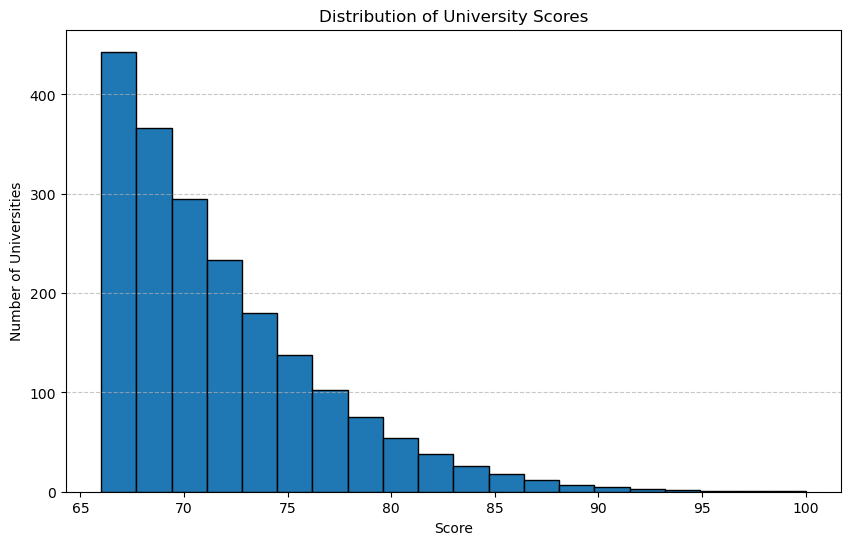

In [481]:
plt.figure(figsize=(10, 6))
plt.hist(word_df['Score'], bins=20, edgecolor='black')
plt.xlabel('Score')
plt.ylabel('Number of Universities')
plt.title('Distribution of University Scores')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

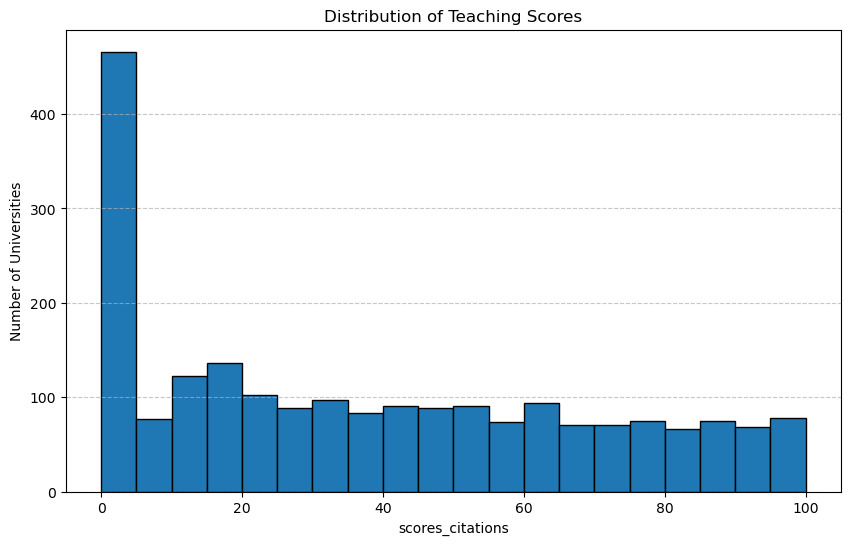

In [482]:
plt.figure(figsize=(10, 6))
plt.hist(times_df["scores_citations"], bins=20, edgecolor='black')
plt.xlabel('scores_citations')
plt.ylabel('Number of Universities')
plt.title('Distribution of Teaching Scores')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

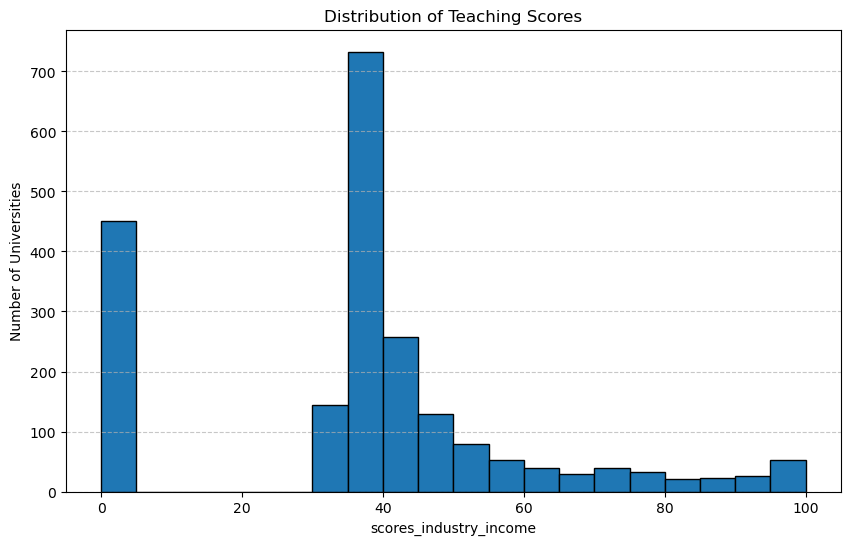

In [483]:
plt.figure(figsize=(10, 6))
plt.hist(times_df["scores_industry_income"], bins=20, edgecolor='black')
plt.xlabel("scores_industry_income")
plt.ylabel('Number of Universities')
plt.title('Distribution of Teaching Scores')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

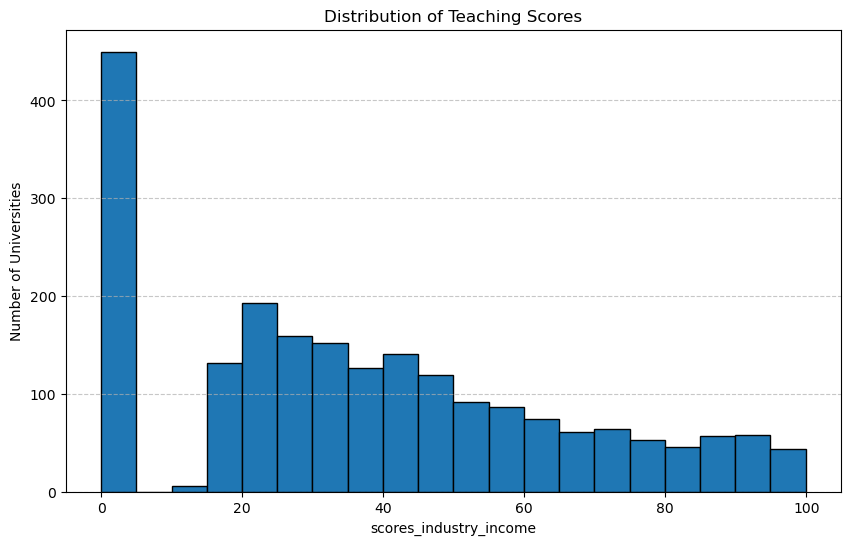

In [484]:
plt.figure(figsize=(10, 6))
plt.hist(times_df["scores_international_outlook"], bins=20, edgecolor='black')
plt.xlabel("scores_industry_income")
plt.ylabel('Number of Universities')
plt.title('Distribution of Teaching Scores')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [485]:
times_df=times_df[times_df["rank"] != 0]

## save the location on new var to visualize it.

# Q1

### times

/var/folders/8x/lx_l3ybs0yx0nx_wtwwkvy6c0000gn/T/ipykernel_48048/4102201087.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


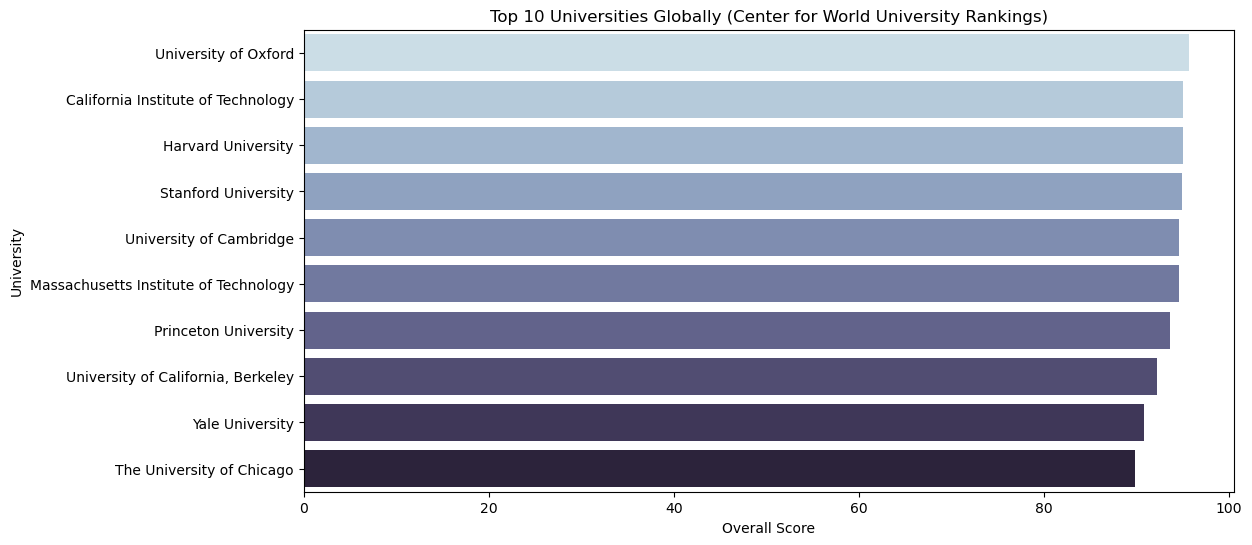

In [486]:
top_10_universities = times_df.head(10)
# Define a color palette for the bars
palette = sns.color_palette("ch:s=.25,rot=-.25", len(top_10_universities))

# Create a horizontal bar chart using the defined palette
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_10_universities["scores_overall"].astype(float), 
    y=top_10_universities["name"], 
    palette=palette
)

plt.xlabel("Overall Score")
plt.ylabel("University")
plt.title("Top 10 Universities Globally (Center for World University Rankings)")
plt.gca()  # Invert y-axis to show the top university at the top

# Display the chart
plt.show()
 

### word

/var/folders/8x/lx_l3ybs0yx0nx_wtwwkvy6c0000gn/T/ipykernel_48048/3655037585.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/8x/lx_l3ybs0yx0nx_wtwwkvy6c0000gn/T/ipykernel_48048/3655037585.py:9: UserWarning: The palette list has more values (10) than needed (8), which may not be intended.
  sns.barplot(


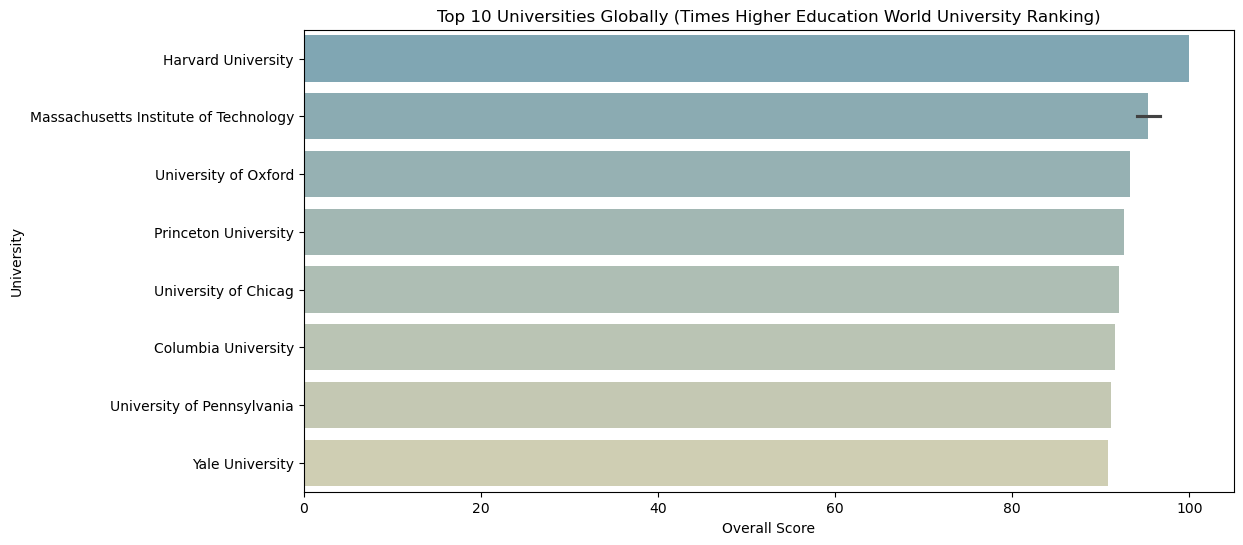

In [487]:
# Extract the top 10 universities from the "Word Rank University" dataset
top_10_world_rank = word_df.head(10)

# Define a color palette for the bars
palette = sns.color_palette("blend:#7AB,#EDA", len(top_10_world_rank))

# Create a horizontal bar chart using the defined palette
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_10_world_rank["Score"].astype(float), 
    y=top_10_world_rank["University Names"], 
    palette=palette
)

plt.xlabel("Overall Score")
plt.ylabel("University")
plt.title("Top 10 Universities Globally (Times Higher Education World University Ranking)")
plt.gca()  # Invert y-axis to show the top university at the top

# Display the chart
plt.show()


### shangai

/var/folders/8x/lx_l3ybs0yx0nx_wtwwkvy6c0000gn/T/ipykernel_48048/1402698814.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


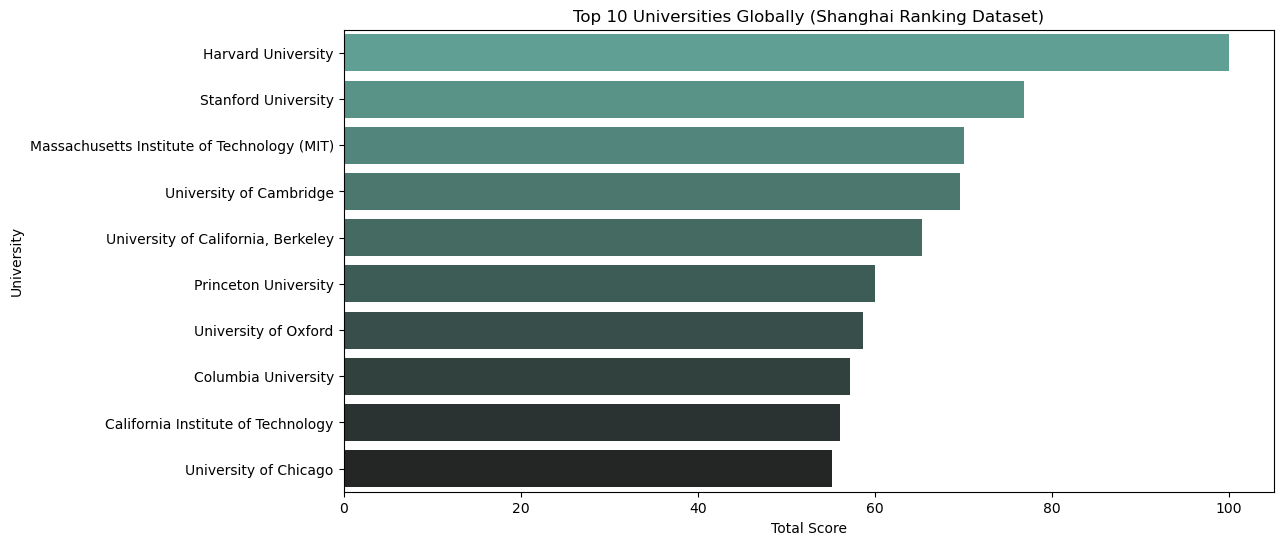

In [488]:

top_10_shanghai = shanghai_df.head(10)

# Define a color palette
palette = sns.color_palette("dark:#5A9_r",  len(top_10_shanghai))

# Create a bar chart with a color palette
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_10_shanghai["Total Score"].astype(float), 
    y=top_10_shanghai["University Name"], 
    palette=palette
)

plt.xlabel("Total Score")
plt.ylabel("University")
plt.title("Top 10 Universities Globally (Shanghai Ranking Dataset)")
plt.gca()  # Invert y-axis to show the top university at the top
plt.show()


# Times

# cant use shangai because it didn't have Location on it. 
# can't sort it by location.


# Q2

# Word

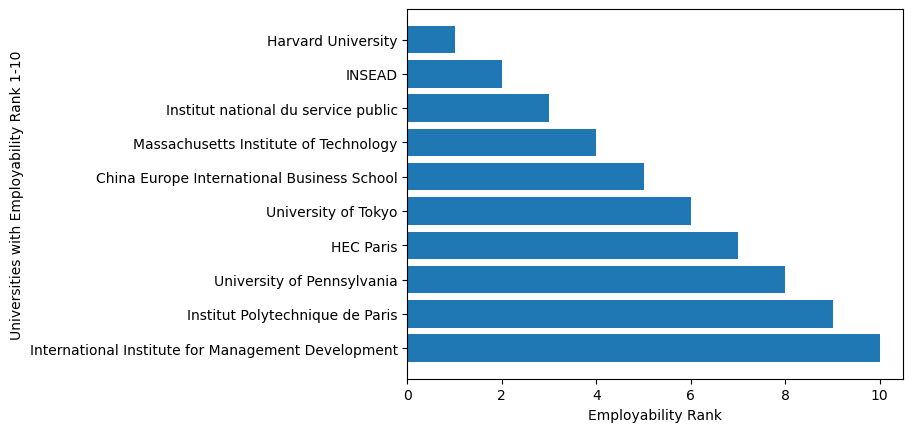

In [489]:
#Q2 
# we need only to use one data "word".
data = word_df[['University Names', 'Employability Rank']]

filtered_data = data[(data['Employability Rank'] > 0) & (data['Employability Rank'] <= 10)]

sorted_data = filtered_data.sort_values(by='Employability Rank')

plt.barh(sorted_data['University Names'], sorted_data['Employability Rank'])
plt.xlabel('Employability Rank')
plt.ylabel('Universities with Employability Rank 1-10')
plt.gca().invert_yaxis()  # Invert y-axis for proper rank order
plt.show()



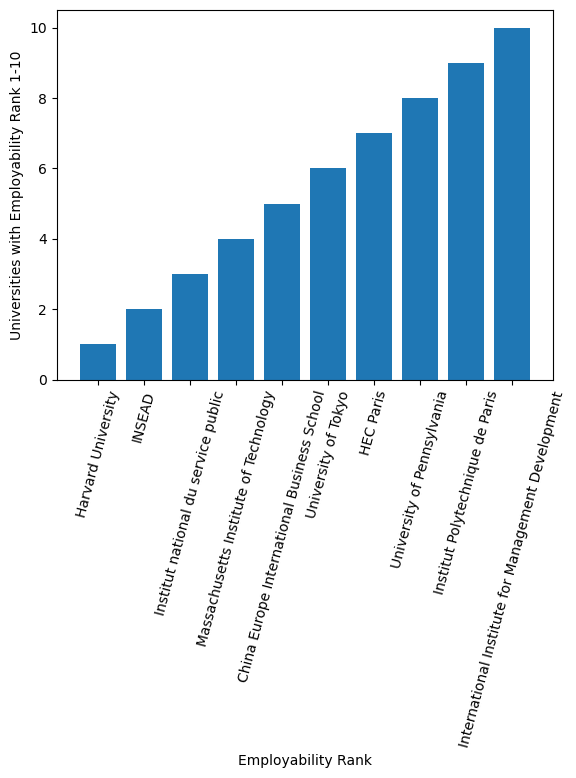

In [490]:
#Q2 
# we need only to use one data "word".
data = word_df[['University Names', 'Employability Rank']]

filtered_data = data[(data['Employability Rank'] > 0) & (data['Employability Rank'] <= 10)]

sorted_data = filtered_data.sort_values(by='Employability Rank')

plt.bar(sorted_data['University Names'], sorted_data['Employability Rank'])
plt.xlabel('Employability Rank')
plt.ylabel('Universities with Employability Rank 1-10')
plt.gca()  # Invert y-axis for proper rank order
plt.xticks(rotation=75)

plt.show()



# can't use times, shangai dataset, because it didn't have the employability rank on it.

# Q3

# Word

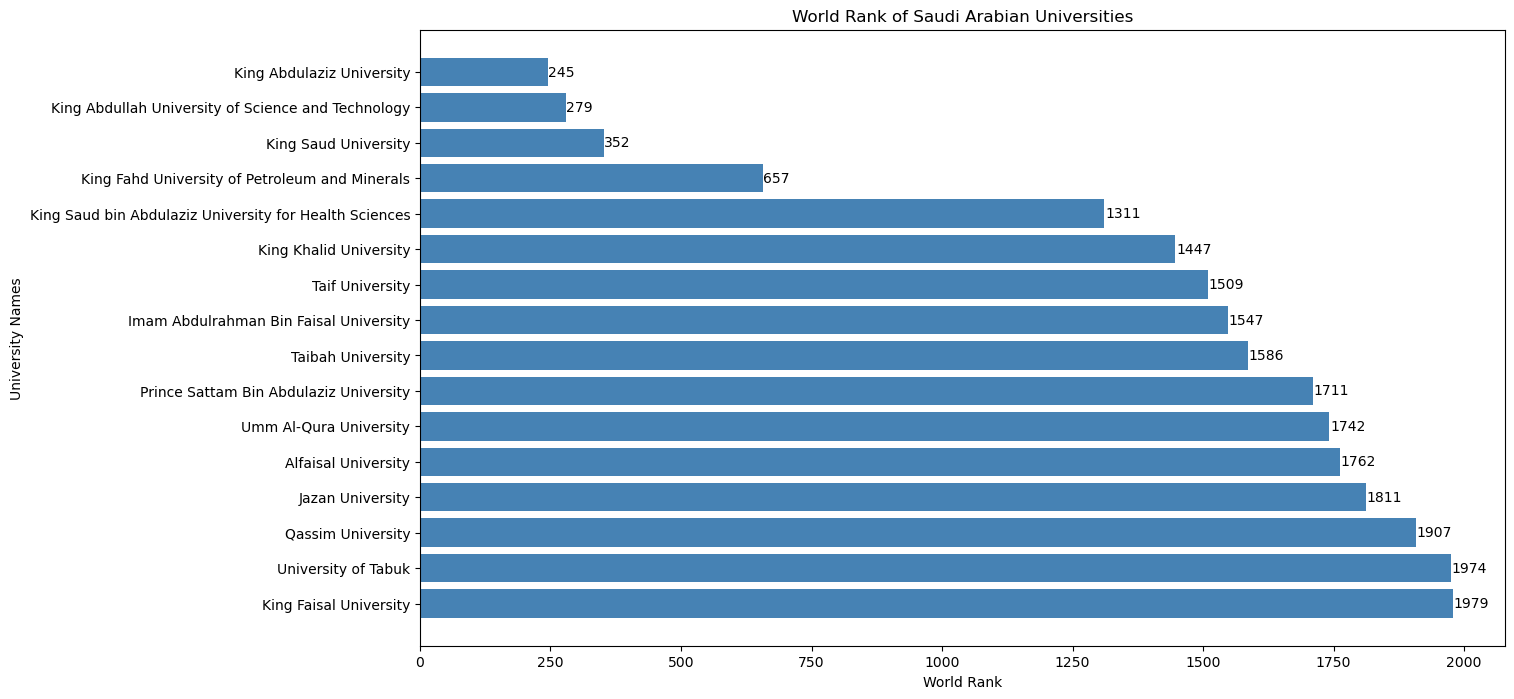

In [491]:
#Q3 
# showing the Saudi University's.

saudi_uni = word_df[(word_df["Location "] == "Saudi Arabia") & (word_df["World Rank"].notnull())]

saudi_uni = saudi_uni.sort_values(by='World Rank')

plt.figure(figsize=(14, 8))
plt.barh(saudi_uni['University Names'], saudi_uni['World Rank'], color='steelblue')
plt.xlabel('World Rank')
plt.ylabel('University Names')
plt.title('World Rank of Saudi Arabian Universities')
plt.gca().invert_yaxis()  # Invert y-axis for proper rank order

for index, value in enumerate(saudi_uni['World Rank']):
    plt.text(value + 1, index, str(value), va='center')

plt.show()


# times

In [492]:
saudi_universities = times_df[times_df['location'] == 'Saudi Arabia']

# Sort by rank order
saudi_universities_sorted = saudi_universities.sort_values(by='rank_order')

saudi_universities_sorted = saudi_universities_sorted.copy()
saudi_universities_sorted['local_rank'] = range(1, len(saudi_universities_sorted) + 1)

# Selecting relevant columns for the table display
saudi_universities_table = saudi_universities_sorted[['local_rank', 'name', 'rank', 'scores_overall']]

# Renaming columns for better readability
saudi_universities_table.rename(columns={
    'local_rank': 'Saudi Rank',
    'name': 'University Name',
    'rank': 'Global Rank',
    'scores_overall': 'Overall Score'
    }, inplace=True)
saudi_universities_filtered = saudi_universities_table[saudi_universities_table['Global Rank'] != 0]

# Display the table
display(saudi_universities_filtered)



/var/folders/8x/lx_l3ybs0yx0nx_wtwwkvy6c0000gn/T/ipykernel_48048/2197761965.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  saudi_universities_table.rename(columns={


,Saudi Rank,University Name,Global Rank,Overall Score
189,1,King Abdulaziz University,190,54.5
203,2,Alfaisal University,201–250,50.4–53.9
368,3,University of Hail,351–400,44.1–46.0
379,4,King Fahd University of Petroleum and Minerals,351–400,44.1–46.0
380,5,King Saud University,351–400,44.1–46.0
481,6,University of Tabuk,401–500,40.9–44.0
746,7,Prince Sattam Bin Abdulaziz University,601–800,32.0–37.9
787,8,Umm Al-Qura University,601–800,32.0–37.9
866,9,Imam Abdulrahman Bin Faisal University,801–1000,27.2–31.9
893,10,King Khalid University,801–1000,27.2–31.9


# cant use shangai because it didn't have Location on it.

# Q4

## word


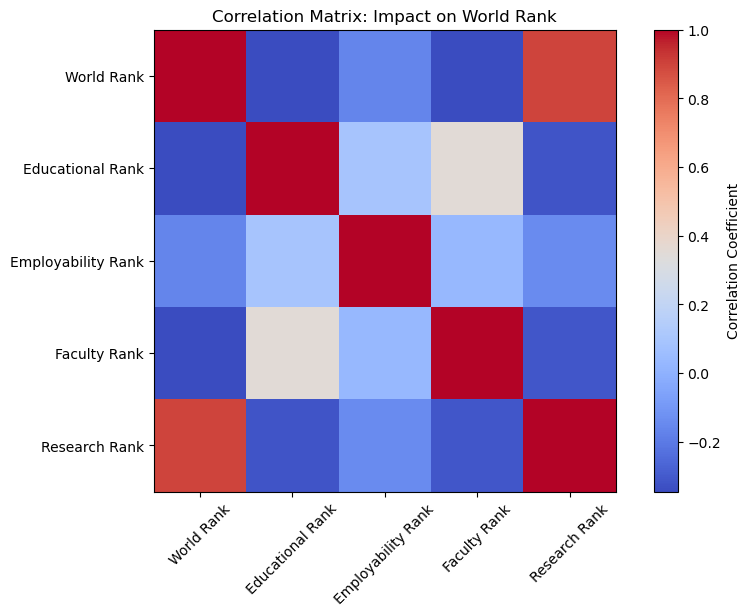

In [493]:
#4
# Ensure 'World Rank' and other rank columns are numeric
word_df['World Rank'] = pd.to_numeric(word_df['World Rank'], errors='coerce')
word_df['Educational Rank'] = pd.to_numeric(word_df['Educational Rank'], errors='coerce')
word_df['Employability Rank'] = pd.to_numeric(word_df['Employability Rank'], errors='coerce')
word_df['Faculty Rank'] = pd.to_numeric(word_df['Faculty Rank'], errors='coerce')
word_df['Research Rank'] = pd.to_numeric(word_df['Research Rank'], errors='coerce')

# Calculate the correlation matrix
correlation_matrix = word_df[['World Rank', 'Educational Rank', 'Employability Rank', 'Faculty Rank', 'Research Rank']].corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 6))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title('Correlation Matrix: Impact on World Rank')
plt.show()


In [494]:
#Q4
#times >>> tommorow



In [495]:
# # Convert scores_overall to numeric (handle ranges by taking the lower bound) for the entire dataset
# times_df['scores_overall'] = times_df['scores_overall'].astype(str).str.split('–').str[0].astype(float)

# # Convert other score columns to numeric
# score_columns = [
#     'scores_overall', 'scores_teaching', 'scores_research', 'scores_citations',
#     'scores_industry_income', 'scores_international_outlook'
# ]

# for col in score_columns[1:]:  # Exclude scores_overall as it's already handled
#     times_df[col] = pd.to_numeric(times_df[col], errors='coerce')

# # Compute correlation matrix for the entire dataset
# correlation_matrix_all = times_df[score_columns].corr()

# # Plot heatmap
# plt.figure(figsize=(8, 6))
# sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt=".2f")
# plt.title('Correlation of Factors with Overall Score (Full Dataset)')
# plt.show()

# # Get the most correlated feature with overall ranking
# most_correlated_feature_all = correlation_matrix_all['scores_overall'].drop('scores_overall').idxmax()
# most_correlation_value_all = correlation_matrix_all['scores_overall'].drop('scores_overall').max()

# most_correlated_feature_all, most_correlation_value_all


# Q5

# Word

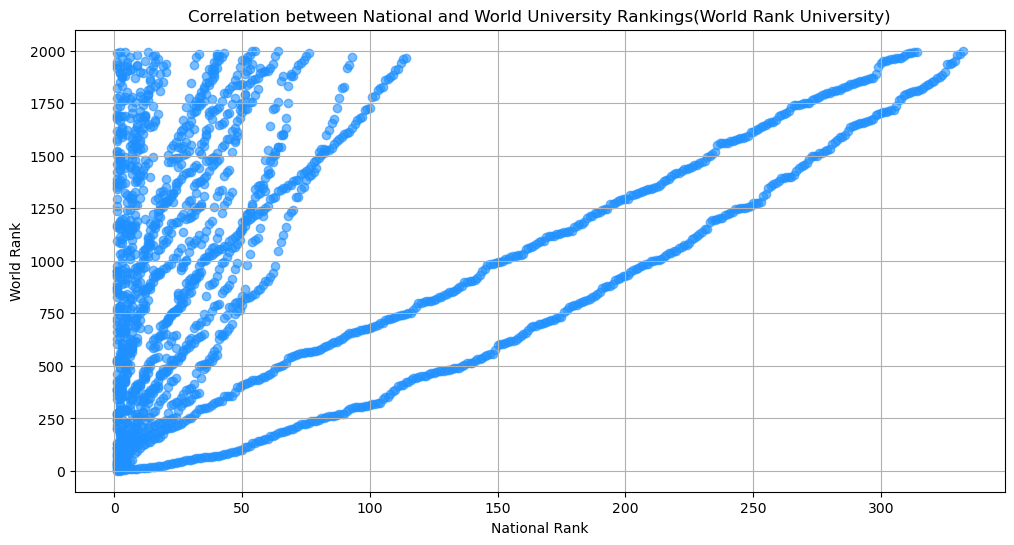

In [496]:
#Q5
# Convert 'World Rank' and 'National Rank' to numeric
word_df['World Rank'] = pd.to_numeric(word_df['World Rank'], errors='coerce')
word_df['National Rank'] = pd.to_numeric(word_df['National Rank'], errors='coerce')

# Drop rows with missing ranks
filtered_df = word_df.dropna(subset=['World Rank', 'National Rank'])


# Plot a scatter plot to visualize the correlation
plt.figure(figsize=(12, 6))
plt.scatter(filtered_df['National Rank'], filtered_df['World Rank'], alpha=0.6, color='dodgerblue')
plt.xlabel('National Rank')
plt.ylabel('World Rank')
plt.title('Correlation between National and World University Rankings(World Rank University)')
plt.grid(True)
plt.show()



In [497]:
word_df["Location "].describe()

count     2000
unique      95
top        USA
freq       332
Name: Location , dtype: object

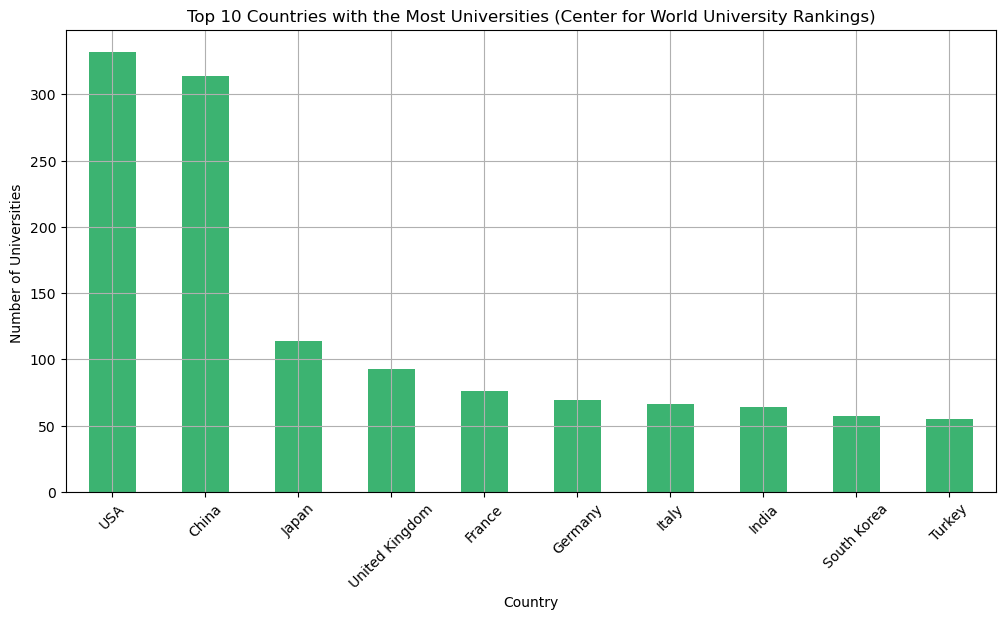

In [498]:

count_word = word_df["Location "].value_counts()

plt.figure(figsize=(12, 6))
count_word.head(10).plot(kind='bar', color='mediumseagreen')
plt.xlabel('Country')
plt.ylabel('Number of Universities ')
plt.title('Top 10 Countries with the Most Universities (Center for World University Rankings)')
plt.xticks(rotation=45)
plt.grid()
plt.show()


### times 


In [499]:

y = times_df["location"].value_counts()
y



location
United States     183
Japan             118
United Kingdom    101
China              97
India              71
                 ... 
Ethiopia            1
Palestine           1
Kenya               1
Costa Rica          1
Malta               1
Name: count, Length: 99, dtype: int64

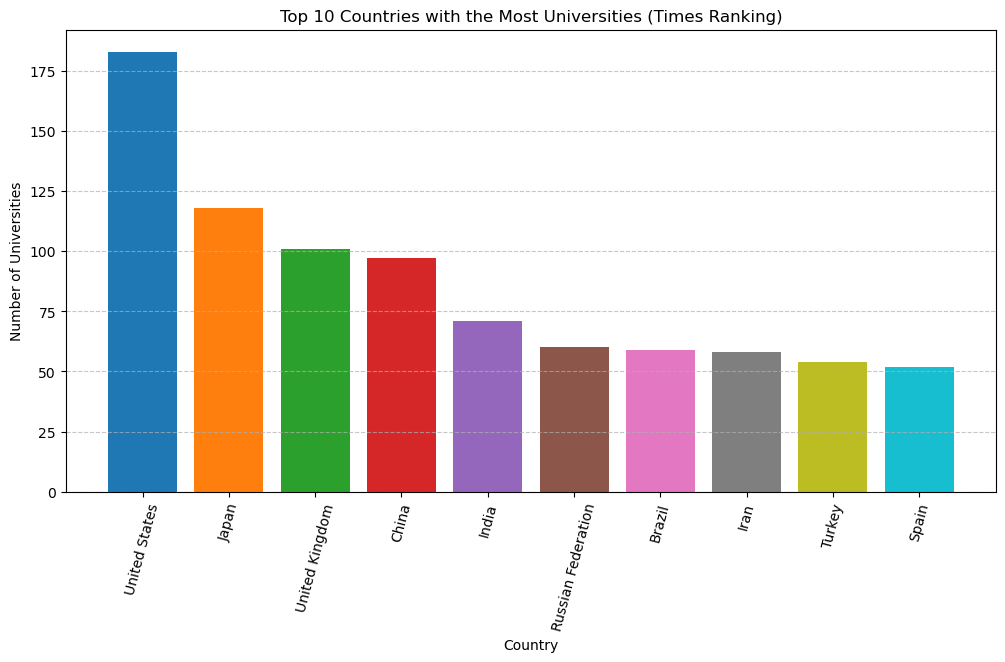

In [500]:
# Define a color palette for the bars
palette = sns.color_palette("tab10", 10)  # Using 'tab10' for distinct colors

# Create a bar chart with the defined palette
plt.figure(figsize=(12, 6))
plt.bar(y[:10].index, y[:10].values, color=palette)
plt.ylabel("Number of Universities")
plt.xlabel("Country")
plt.title("Top 10 Countries with the Most Universities (Times Ranking)")
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Adding a grid for better readability
plt.xticks(rotation=75)

# Display the chart
plt.show()


In [501]:
shanghai_df

,Ranking,University Name,National/Regional Rank,Total Score,University Detail
0,1,Harvard University,1,100.0,http://www.shanghairanking.com/institution/har...
1,2,Stanford University,2,76.8,http://www.shanghairanking.com/institution/sta...
2,3,Massachusetts Institute of Technology (MIT),3,70.1,http://www.shanghairanking.com/institution/mas...
3,4,University of Cambridge,1,69.6,http://www.shanghairanking.com/institution/uni...
4,5,"University of California, Berkeley",4,65.3,http://www.shanghairanking.com/institution/uni...
...,...,...,...,...,...
995,901-1000,University of Wuppertal,46-47,0.0,http://www.shanghairanking.com/institution/uni...
996,901-1000,Warsaw University of Technology,7-11,0.0,http://www.shanghairanking.com/institution/war...
997,901-1000,Western Norway University of Applied Sciences,6-7,0.0,http://www.shanghairanking.com/institution/wes...
998,901-1000,Wroclaw University of Science and Technology,7-11,0.0,http://www.shanghairanking.com/institution/wro...


Correlation between National/Regional Rank and Global Ranking: 0.08


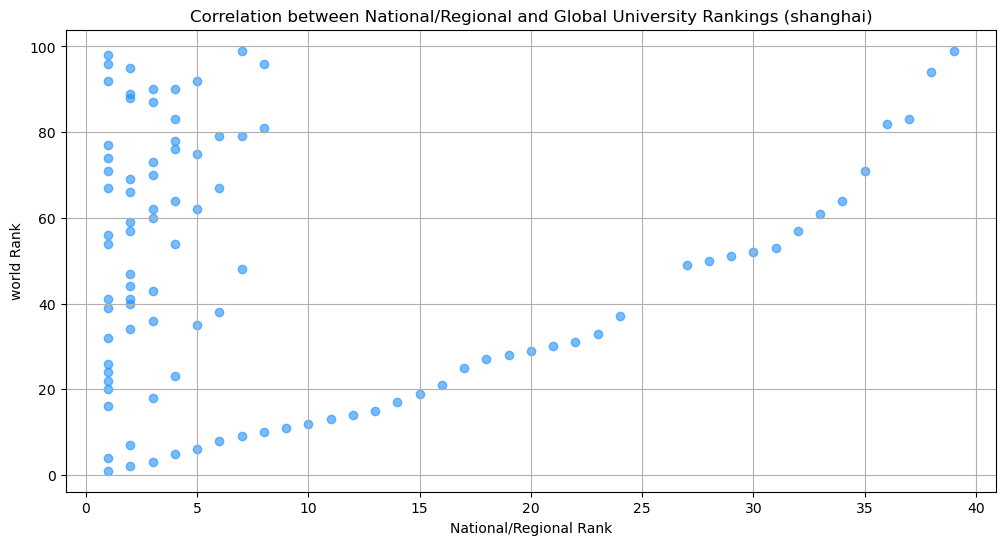

In [502]:
#Q5 

# Ensure 'Ranking' and 'National/Regional Rank' are numeric
shanghai_df['Ranking'] = pd.to_numeric(shanghai_df['Ranking'], errors='coerce')
shanghai_df['National/Regional Rank'] = pd.to_numeric(shanghai_df['National/Regional Rank'], errors='coerce')

# Drop rows with missing or non-numeric rankings
filtered_df = shanghai_df.dropna(subset=['Ranking', 'National/Regional Rank'])

# Calculate correlation
correlation = np.corrcoef(filtered_df['National/Regional Rank'], filtered_df['Ranking'])[0, 1]
print(f"Correlation between National/Regional Rank and Global Ranking: {correlation:.2f}")

# Plot a scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(filtered_df['National/Regional Rank'], filtered_df['Ranking'], alpha=0.6, color='dodgerblue')
plt.xlabel('National/Regional Rank')
plt.ylabel('world Rank')
plt.title('Correlation between National/Regional and Global University Rankings (shanghai)')
plt.grid(True)
plt.show()


#we cant answer the second part of this Q, because it didn't have the column country on it. 




# Q6 

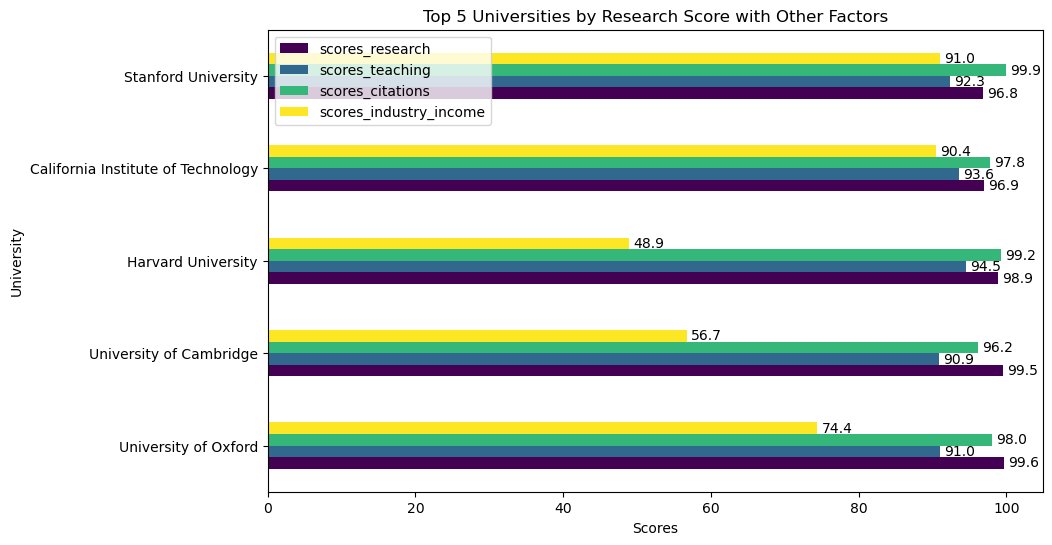

In [503]:
top_5_universities = times_df.nlargest(5, 'scores_research')[['name', 'scores_research', 'scores_teaching', 'scores_citations', 'scores_industry_income']]

# Plot with horizontal bars and values displayed
fig, ax = plt.subplots(figsize=(10, 6))

top_5_universities.set_index('name').plot(kind='barh', ax=ax, colormap="viridis")

# Adding text labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=10, label_type='edge', padding=3)

plt.title('Top 5 Universities by Research Score with Other Factors')
plt.xlabel('Scores')
plt.ylabel('University')
plt.show()

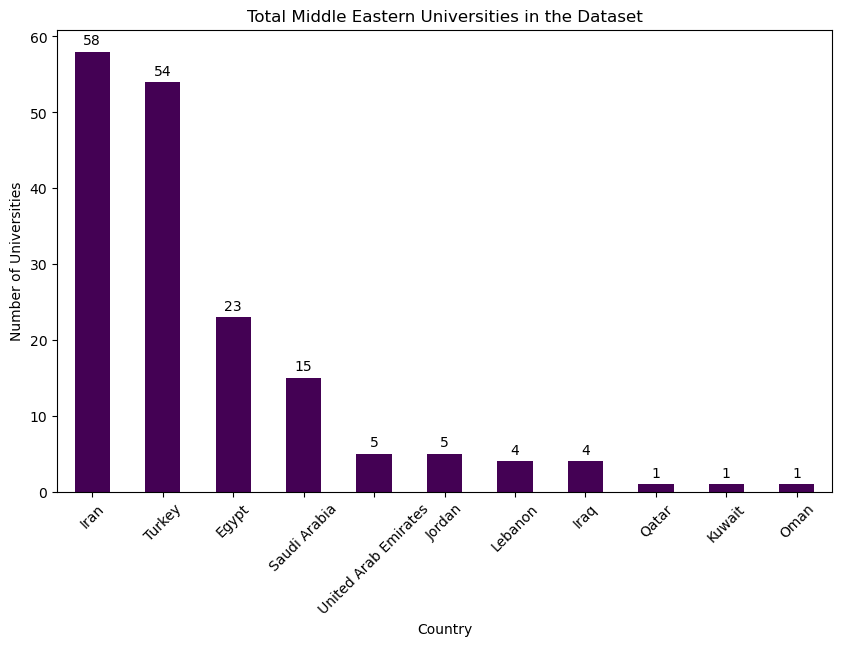

location
Iran                    58
Turkey                  54
Egypt                   23
Saudi Arabia            15
United Arab Emirates     5
Jordan                   5
Lebanon                  4
Iraq                     4
Qatar                    1
Kuwait                   1
Oman                     1
Name: count, dtype: int64

In [505]:
# Define Middle Eastern countries
middle_east_countries = [
    'Saudi Arabia', 'United Arab Emirates', 'Qatar', 'Kuwait', 'Oman', 'Bahrain', 'Jordan',
    'Lebanon', 'Iraq', 'Egypt', 'Turkey', 'Iran'
]

# Filter Middle Eastern universities
middle_east_universities = times_df[times_df['location'].isin(middle_east_countries)]

# Count the number of Middle Eastern universities per country
middle_east_university_distribution = middle_east_universities['location'].value_counts()

# Plot the distribution
fig, ax = plt.subplots(figsize=(10, 6))
middle_east_university_distribution.plot(kind='bar', colormap="viridis", ax=ax)

# Add text labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10, label_type='edge', padding=3)

plt.title('Total Middle Eastern Universities in the Dataset')
plt.ylabel('Number of Universities')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.show()

# Display the total count of Middle Eastern universities
middle_east_university_distribution

#### I. Categorical Variables:

we’ll use frequency table to understand distribution of each category
- Bar Chart (Ordinal) - Orderd
- Pie Chart (Nominal) - non Orderd

#### II. Numerical Variables:

we need to understand the central tendency and spread of the variable (Descriptive Analysis) using:
   - Box plot
   - Histogram

### 2. Univariate Non-Graphical analysis: 

- Where is the center of the data? (location) --> **Measures of central tendency**
- How much does the data vary? (scale) --> **Measure of variability**
- What is the shape of the data? (shape) --> **Measures of variation combined with an average (measure of center) gives a good picture of the distribution of the data.**

In [506]:
word_df.dtypes

World Rank              int64
University Names       object
Location               object
National Rank           int64
Educational Rank        int64
Employability Rank      int64
Faculty Rank            int64
Research Rank           int64
Score                 float64
Rank_%                float64
dtype: object

In [507]:
word_df.describe().T

,count,mean,std,min,25%,50%,75%,max
World Rank,2000.0,1000.50000,577.494589,1.0,500.75,1000.5,1500.25,2000.0
National Rank,2000.0,69.24500,85.538608,1.0,9.75,33.0,89.00,332.0
Educational Rank,2000.0,60.04250,137.715284,0.0,0.00,0.0,0.00,552.0
Employability Rank,2000.0,407.17600,539.997212,0.0,0.00,33.5,793.25,1713.0
Faculty Rank,2000.0,18.97100,56.385901,0.0,0.00,0.0,0.00,282.0
Research Rank,2000.0,935.77000,576.062685,0.0,434.75,934.5,1434.25,1996.0
Score,2000.0,71.75555,5.038800,66.0,67.90,70.4,74.30,100.0
Rank_%,2000.0,4.92325,2.812967,0.1,2.50,4.9,7.40,9.8


In [508]:
times_df.dtypes

rank_order                        int64
rank                             object
name                             object
scores_overall                   object
scores_teaching                 float64
scores_research                 float64
scores_citations                float64
scores_industry_income          float64
scores_international_outlook    float64
location                         object
dtype: object

In [509]:
times_df.head()

,rank_order,rank,name,scores_overall,scores_teaching,scores_research,scores_citations,scores_industry_income,scores_international_outlook,location
0,10,1,University of Oxford,95.7,91.0,99.6,98.0,74.4,96.3,United Kingdom
1,20,2,California Institute of Technology,95.0,93.6,96.9,97.8,90.4,83.8,United States
2,30,2,Harvard University,95.0,94.5,98.9,99.2,48.9,79.8,United States
3,40,4,Stanford University,94.9,92.3,96.8,99.9,91.0,79.7,United States
4,50,5,University of Cambridge,94.6,90.9,99.5,96.2,56.7,95.8,United Kingdom


In [510]:
times_df=times_df[times_df["rank"] != 0]

In [511]:
times_df.shape

(1662, 10)

In [512]:
times_df.describe().T

,count,mean,std,min,25%,50%,75%,max
rank_order,1662.0,8314.993983,4799.227370,10.0,4162.500,8315.0,12467.500,16620.0
scores_teaching,1662.0,27.460529,13.220974,11.9,18.500,23.3,32.000,94.5
scores_research,1662.0,23.077497,16.745298,7.4,11.600,17.1,28.900,99.6
scores_citations,1662.0,48.088327,27.570528,0.7,23.225,46.2,70.900,100.0
scores_industry_income,1662.0,46.599338,16.429355,34.8,35.925,39.5,48.900,100.0
scores_international_outlook,1662.0,46.943562,22.950696,13.8,27.400,42.3,62.575,99.9


In [513]:
# cita_times_5=times_df["scores_citations"].quantile(0.05)
# cita_times_95=times_df["scores_citations"].quantile(0.95)

# print(cita_times_5,cita_times_95)

# times_df[(times_df["scores_citations"] < cita_times_5) | (times_df["scores_citations"] > cita_times_95)]

In [514]:
shanghai_df.dtypes

Ranking                   float64
University Name            object
National/Regional Rank    float64
Total Score               float64
University Detail          object
dtype: object

In [515]:
shanghai_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Ranking,100.0,50.29000,28.851166,1.0,25.75,50.5,75.25,99.0
National/Regional Rank,229.0,6.28821,8.104303,1.0,1.00,3.0,7.00,39.0
Total Score,1000.0,5.94350,12.379624,0.0,0.00,0.0,7.50,100.0


## 4. Bivariate/Multivariate Analysis:

Here, you look at the relationships between two or more variables. This can involve looking for correlations, patterns, and trends that suggest a relationship or an association.

We can perform bi-variate analysis for any combination of categorical and numerical variables. The combination can be:
| bi-variate variables   | Plot type |
| ------------- | ------------- |
| Categorical & Categorical| Stacked Bar Chart |
| Categorical & numerical  | scatter plot, histogram, box plot|
| numerical  & numerical  | Scatter plot, line chart| 


Multivariate Analysis:
- Heat map
- Bar Chart
- Scatter Chart
- Line Chart

**Categorical & Categorical --> (Stacked Column Chart)**

**Categorical & numerical --> (scatter plot, histogram, box plot)**

**numerical & numerical --> (Scatter plot, line chart)**

We could also use a correlation matrix to get more specific information about the relationship between these two variables.